In [1]:
!rsync -avz cluster.ies:/mnt/work/dhuseljic/experiments/mlflow/perf_dal /home/dhuseljic/mlflow

receiving incremental file list
perf_dal/
perf_dal/optimal.db

sent 32,177 bytes  received 1,826,864 bytes  531,154.57 bytes/sec
total size is 32,051,200  speedup is 17.24


In [1]:
import os 
import mlflow
import torch
import numpy as np
import pylab as plt
import pandas as pd
import matplotlib

os.makedirs('plots', exist_ok=True)
matplotlib.rcParams['figure.figsize'] = (4, 3)
torch.set_grad_enabled(False)

## Strategies

In [5]:
from collections import defaultdict

exp_name = 'optimal_v2'
dataset = 'dtd'
uri = 'sqlite:////home/dhuseljic/mlflow/perf_dal/optimal.db' # uri = 'file:////home/dhuseljic/mlflow/perf_dal/optimal/'
query_list = [f"parameter.dataset_name= '{dataset}'"]

client = mlflow.tracking.MlflowClient(tracking_uri=uri)
experiment_id = client.get_experiment_by_name(exp_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
print('Found {} experiments'.format(len(runs_strategies)))

runs_per_strat = defaultdict(list)
acc_curves_strategies = defaultdict(list)
for run in runs_strategies:
    key = run.data.params['al.strategy']
    runs_per_strat[key].append(run)
    acc_curves_strategies[key].append([m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')])

acc_curves_random = acc_curves_strategies['random']

for key in  acc_curves_strategies:
    print(f"{key:10}: {len(acc_curves_strategies[key]):3}")

run = runs_per_strat['optimal'][0]
params = run.data.params
{key: val for key, val in params.items() if key.startswith('al')}

Found 80 experiments
optimal   :  20
margin    :  20
typiclust :  20
random    :  20


{'al.strategy': 'optimal',
 'al.subset_size': 'None',
 'al.init_method': 'random',
 'al.num_init_samples': 'None',
 'al.acq_size': '50',
 'al.num_acq': '20',
 'al.device': 'cpu',
 'al.optimal.num_batches': '900',
 'al.optimal.batch_types': "['random', 'diverse', 'uncertain']",
 'al.optimal.gamma': '7',
 'al.optimal.num_mc_labels': '10',
 'al.optimal.use_true_labels': 'True',
 'al.optimal.use_retraining': 'True',
 'al.optimal.num_retraining_epochs': '50',
 'al.optimal.use_val_ds': 'True',
 'al.optimal.loss': 'cross_entropy'}

In [6]:
acq_size = int(runs_per_strat['random'][0].data.params['al.acq_size'])
num_acq = int(runs_per_strat['random'][0].data.params['al.num_acq'])
axis = np.arange(acq_size, (acq_size*(num_acq+1))+1, acq_size)

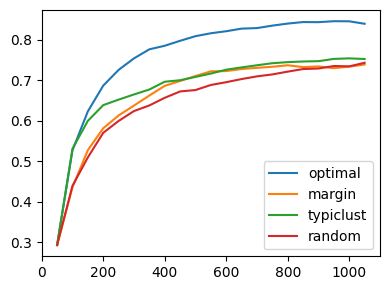

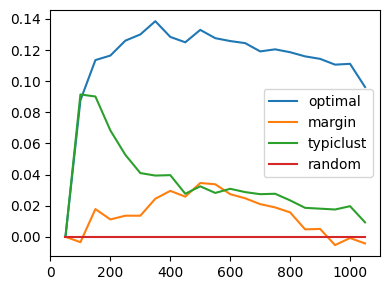

In [7]:
plt.figure(figsize=(4, 3))
for key in acc_curves_strategies:
    plt.plot(axis, np.mean(acc_curves_strategies[key], axis=0), label=key)
plt.tight_layout()
plt.legend()
plt.savefig(f'plots/{dataset}_lc_strats.pdf')

plt.figure(figsize=(4, 3))
for key in acc_curves_strategies:
    plt.plot(axis, np.mean(acc_curves_strategies[key], axis=0) - np.mean(acc_curves_random, axis=0), label=key)
plt.tight_layout()
plt.legend()
plt.savefig(f'plots/{dataset}_lcdiff_strats.pdf')

In [268]:
bought_dict = defaultdict(list)
buy_matrix = []
for run in runs_per_strat['optimal']:
    bought_random = [m.value for m in client.get_metric_history(run.info.run_id, 'bought_random')]
    bought_diverse = [m.value for m in client.get_metric_history(run.info.run_id, 'bought_diverse')]
    bought_uncertain = [m.value for m in client.get_metric_history(run.info.run_id, 'bought_uncertain')]

    bought_dict['bought_random'].append(bought_random) 
    bought_dict['bought_diverse'].append(bought_diverse) 
    bought_dict['bought_uncertain'].append(bought_uncertain) 

    buys_m = np.stack((bought_random, bought_diverse, bought_uncertain), axis=1)
    buy_matrix.append(buys_m[1:] - buys_m[:-1])

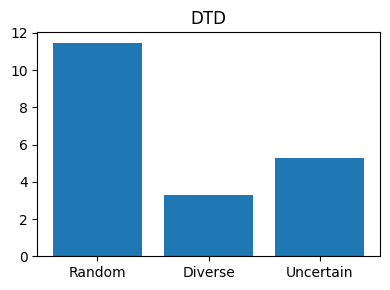

In [269]:
bought_random = np.mean(np.array(bought_dict['bought_random'])[:, -1])
bought_diverse = np.mean(np.array(bought_dict['bought_diverse'])[:, -1])
bought_uncertain = np.mean(np.array(bought_dict['bought_uncertain'])[:, -1])

x = np.arange(3)
plt.title(f'{dataset.upper()}')
plt.bar(x, [bought_random, bought_diverse, bought_uncertain], tick_label=['Random', 'Diverse', 'Uncertain'])
plt.tight_layout()
plt.savefig(f'plots/{dataset}_bought_overall.pdf')
plt.show()

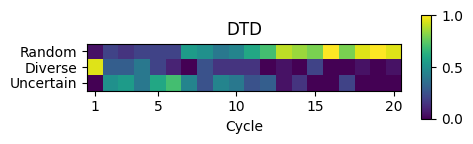

In [270]:
plt.figure(figsize=(5, 5))
plt.title(dataset.upper())
plt.imshow(np.mean(buy_matrix, axis=0).T, vmin=0, vmax=1)
plt.yticks([0, 1, 2], ['Random', 'Diverse', 'Uncertain'])
plt.xticks([0, 4, 9, 14, 19], [1, 5, 10, 15, 20])
plt.xlabel('Cycle')
plt.colorbar(location='right', shrink=.22, aspect=10)
plt.tight_layout()
plt.savefig(f'plots/{dataset}_bought_per_cycle.pdf', bbox_inches='tight')
plt.show()

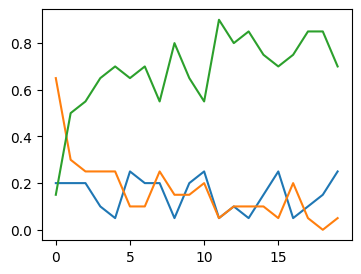

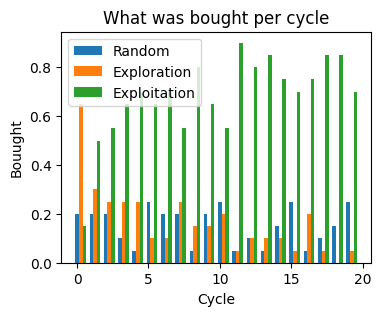

In [243]:
buy_matrix_mean = np.mean(buy_matrix, axis=0)
bought_random_mean = buy_matrix_mean[:, 0]
bought_diverse_mean = buy_matrix_mean[:, 1]
bought_uncertain_mean = buy_matrix_mean[:, 2]
labels = ['Random', 'Exploration', 'Exploitation']

plt.plot(bought_random_mean )
plt.plot(bought_diverse_mean )
plt.plot(bought_uncertain_mean )
plt.show()

bar_width = 0.25  # Width of the bars
x = np.arange(len(bought_random_mean)) # Position of bars on x-axis
fig, ax = plt.subplots()
for i, vals in enumerate([bought_random_mean, bought_diverse_mean, bought_uncertain_mean]):
    ax.bar(x + i * bar_width, vals, width=bar_width, label=labels[i])

#zoom_ax = fig.add_axes([0.25, 0.5, 0.25, 0.35])  # (x_position, y_position, width, height)

# Adding value labels on top of each bar
# Set the labels
ax.set_xlabel('Cycle')
ax.set_ylabel('Bouught')
ax.set_title('What was bought per cycle')
ax.legend()
plt.show()


### Plot sampled images

In [50]:
import json
from pathlib import Path

def download_artifacts(run, to_path=Path.home() / 'server_artifacts'):
    global_uri = Path(run.info.artifact_uri)
    local_uri = Path(*global_uri.parts[-4:])
    dest = to_path / local_uri
    os.makedirs(dest, exist_ok=True)
    print(f'Downloading artifacts from {global_uri} to {dest}')
    os.system(f'rsync -avz cluster.ies:{global_uri}/ {dest}')
    return dest


Seed set to 42


receiving incremental file list

sent 20 bytes  received 363 bytes  255.33 bytes/sec
total size is 1,931  speedup is 5.04
Files already downloaded and verified
Files already downloaded and verified
Found 10 classes


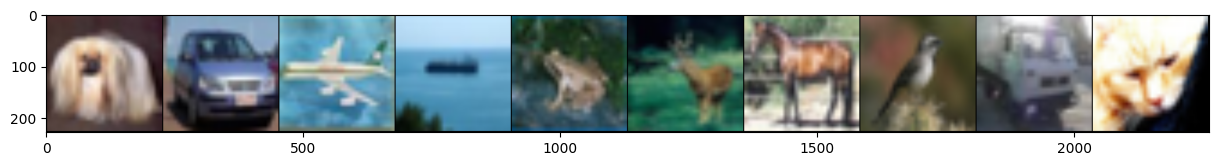

In [148]:
import torch
import sys
import argparse
sys.path.append('..')
from utils import build_image_data
from dal_toolbox.utils import seed_everything
from torchvision.utils import make_grid

strat = 'optimal'
artifact_path = download_artifacts(run)
query_indices_dict = {}
for i_acq in range(0, 21):
    run = runs_per_strat[strat][0]
    with open(artifact_path / f'query_indices_{i_acq:02d}', "r") as f:
        data = json.load(f)
    query_indices_dict[i_acq] = eval(data['query_indices'])

args = argparse.Namespace(dataset_name=run.data.params['dataset_name'], dataset_path='/home/datasets')
seed_everything(42)
ds = build_image_data(args, plain_transforms=True)
query_ds = ds.train_dataset

i_acq = 1
query_indices = query_indices_dict[i_acq]
imgs = torch.stack([query_ds[idx][0] for idx in query_indices], dim=0)
labels = torch.Tensor([query_ds[idx][1] for idx in query_indices])
uniques, counts = labels.unique(return_counts=True)
print(f'Found {len(uniques)} classes')

img_grid = make_grid(imgs[:32], nrow=16)
plt.figure(figsize=(15, 5))
plt.imshow(img_grid.permute(1, 2, 0))
plt.show()

In [149]:
from torch.utils.data import DataLoader
from dal_toolbox.datasets.utils import DinoTransforms
device ='cuda'

tsne_indices = torch.randperm(len(query_ds))[:1000]
tsne_indices = torch.cat((tsne_indices, torch.tensor(query_indices))).unique()

query_ds.dataset.transform = DinoTransforms(size=(256, 256)).transform
dl = DataLoader(query_ds, sampler=tsne_indices, batch_size=128)
model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')

features = []
labels = []
model.eval()
model.to(device)
for batch in dl:
    features.append(model(batch[0].to(device)).to('cpu'))
    labels.append(batch[-1])
features = torch.cat(features)
labels = torch.cat(labels)

Using cache found in /home/dhuseljic/.cache/torch/hub/facebookresearch_dinov2_main


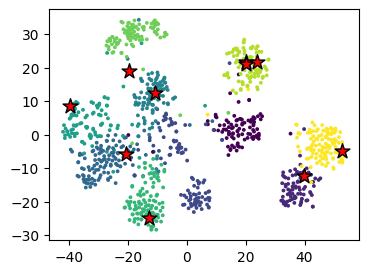

In [152]:
from sklearn.manifold import TSNE

tsne = TSNE()
features_tsne = tsne.fit_transform(features)

plt.scatter(features_tsne[:, 0], features_tsne[:, 1], c=labels, s=3)
plt.scatter(features_tsne[-10:, 0], features_tsne[-10:, 1], c='red', s=125, marker='*', lw=1, ec='k')


## Batch Selection

In [22]:
from collections import defaultdict
runs = []

dataset = 'cifar10'
exp_name = 'batch_selection_v1'
uri = 'sqlite:////home/dhuseljic/mlflow/perf_dal/optimal.db' 

client = mlflow.tracking.MlflowClient(tracking_uri=uri)

# experiment_id = client.get_experiment_by_name('optimal_v1').experiment_id
# query_list = [f"parameter.al.strategy = 'random'", f"parameter.dataset_name= '{dataset}'",]
# runs_random = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
# runs.extend(runs_random)

# experiment_id = client.get_experiment_by_name('optimal_v1').experiment_id
# query_list = [f"parameter.al.strategy = 'typiclust'", f"parameter.dataset_name= '{dataset}'",]
# runs_typiclust = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
# runs.extend(runs_typiclust)

experiment_id = client.get_experiment_by_name('batch_selection_v1').experiment_id
query_list = [
    f"parameter.al.strategy = 'optimal'",
    f"parameter.dataset_name = '{dataset}'", 
    f"parameter.al.optimal.num_batches= '30'", 
]
runs_optimal = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
runs.extend(runs_optimal)
print('Found {} experiments'.format(len(runs)))

# Adapt runs 
for run in runs:
    al_strat = run.data.params['al.strategy']
    if al_strat == 'optimal':
        batch_types = eval(run.data.params['al.optimal.batch_types'])
        name = f"batches={'+'.join(batch_types)}"
        run.data.params['al.strategy'] = name
        # run.data.params['al.strategy'] = 'diverse'

runs_per_strat = defaultdict(list)
acc_curves = defaultdict(list)
for run in runs:
    key = run.data.params['al.strategy']
    runs_per_strat[key].append(run)
    acc_curves[key].append([m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')])

for key in  acc_curves:
    print(f"{key:10}: {len(acc_curves[key]):3}")

Found 80 experiments
batches=diverse:  20
batches=uncertain:  20
batches=random+diverse+uncertain:  20
batches=random:  20


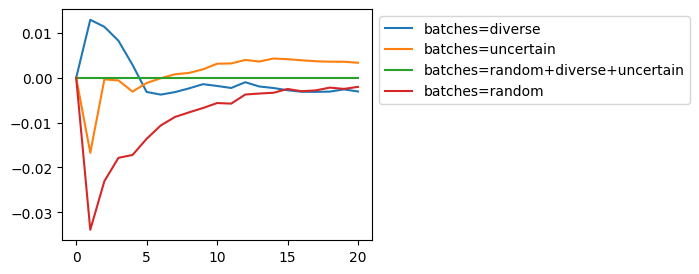

In [26]:
# plt.plot(np.mean(acc_curves_strategies['random'] , axis=0), label='Random')
# for key in acc_curves:
#   plt.plot(np.mean(acc_curves[key], axis=0), label=key)
for key in acc_curves:
    plt.plot(np.mean(acc_curves[key], axis=0) - np.mean(acc_curves['batches=random+diverse+uncertain'], axis=0) , label=key)
    
plt.legend(bbox_to_anchor=(1, 1))